# Customer Churn Prediction

This notebook is built to run and uses three source tables:

- `dim_customer.csv` -> one row per customer, includes the target column `is_churned`
- `fact_customer_activity.csv` -> monthly activity per customer (usage, balance, support tickets, offers)
- A third monthly aggregate report table (churn rate per month) -> **not used here**, because it summarizes churn at the month level, not the customer level. Using it as a feature would leak the target into the model (data leakage).

**Notebook plan:**
1. Upload data
2. Merge tables + feature engineering from the activity table
3. Quick EDA
4. Prepare data for training
5. Train the model
6. Evaluate the model
7. Save the model
8. Simple Gradio interface for live testing


In [1]:
# Install the only extra package we need (Gradio for the demo interface).
# scikit-learn, pandas, joblib are already available in Colab by default.
!pip install gradio -q


## 1. Upload the data

Run the cell below, click "Choose Files", and select `dim_customer.csv` and `fact_customer_activity.csv` together.


In [2]:
from google.colab import files
import pandas as pd

# Opens a file picker. Select both CSV files at once.
uploaded = files.upload()


Saving dim customer.csv to dim customer.csv
Saving fact customer activity.csv to fact customer activity.csv


In [3]:
# Load the two tables we actually need for training.
dim = pd.read_csv('/content/dim customer.csv')
fact = pd.read_csv('/content/fact customer activity.csv')

print('dim_customer shape:', dim.shape)
print('fact_customer_activity shape:', fact.shape)

# Quick look at the customer-level table (this is where our target lives).
dim.head()


dim_customer shape: (1000, 8)
fact_customer_activity shape: (5146, 12)


,cust_key,customer_id,is_churned,CLV_LTV,avg_ticket_res_time_hrs,num_products,dw_start_date,dw_end_date
0,1,15566091,0,834.60,24.280,1,2026-09-03,9999-12-31
1,2,15566111,0,0.00,18.470,1,2026-09-03,9999-12-31
2,3,15566156,0,190448.62,26.150,2,2026-09-03,9999-12-31
3,4,15566292,0,378.95,38.450,2,2026-09-03,9999-12-31
4,5,15566594,0,1078.75,16.185,2,2026-09-03,9999-12-31


## 2. Merge tables and engineer features

`fact_customer_activity` has multiple rows per customer (one row per month).
Since our model needs to make **one prediction per customer**, we first need to summarize
each customer's monthly activity into a single row: totals, averages, and the most recent
month's numbers (as a simple "recency" signal).


In [4]:
# Aggregate monthly activity into one row per customer.
agg = fact.groupby('customer_id').agg(
    months_active=('activity_month', 'nunique'),          # how many months this customer has activity for
    total_usage_events=('usage_events', 'sum'),            # total usage across all months
    avg_usage_events=('usage_events', 'mean'),              # average monthly usage
    avg_total_balance=('total_balance', 'mean'),            # average total balance across months
    avg_balance_mean=('avg_balance', 'mean'),                # average of monthly average balance
    total_tickets=('ticket_count', 'sum'),                  # total support tickets raised
    avg_resolution_time_mean=('avg_resolution_time', 'mean'),  # average support ticket resolution time
    total_offers=('offer_count', 'sum'),                    # total offers sent to the customer
    total_accepted_offers=('accepted_offers', 'sum'),       # total offers the customer accepted
    avg_acceptance_rate=('acceptance_rate', 'mean'),        # average monthly offer acceptance rate
).reset_index()

# Grab each customer's most recent month of activity as a simple recency feature.
fact_sorted = fact.sort_values(['customer_id', 'activity_month'])
last_row = fact_sorted.groupby('customer_id').tail(1)[
    ['customer_id', 'usage_events', 'total_balance', 'ticket_count']
]
last_row.columns = ['customer_id', 'last_usage_events', 'last_total_balance', 'last_ticket_count']

# Combine everything into one training table: customer info + aggregated activity + recency.
merged = dim.merge(agg, on='customer_id', how='left').merge(last_row, on='customer_id', how='left')

print('Merged shape:', merged.shape)
print('Total missing values:', merged.isna().sum().sum())
merged.head()


Merged shape: (1000, 21)
Total missing values: 0


,cust_key,customer_id,is_churned,CLV_LTV,avg_ticket_res_time_hrs,num_products,dw_start_date,dw_end_date,months_active,total_usage_events,...,avg_total_balance,avg_balance_mean,total_tickets,avg_resolution_time_mean,total_offers,total_accepted_offers,avg_acceptance_rate,last_usage_events,last_total_balance,last_ticket_count
0,1,15566091,0,834.60,24.280,1,2026-09-03,9999-12-31,4,4,...,208.6500,104.3250,2,6.0700,2,2,0.50,2,0.00,0
1,2,15566111,0,0.00,18.470,1,2026-09-03,9999-12-31,5,3,...,0.0000,0.0000,1,3.6940,1,1,0.20,1,0.00,0
2,3,15566156,0,190448.62,26.150,2,2026-09-03,9999-12-31,4,2,...,47612.1550,47612.1550,1,6.5375,1,1,0.25,1,100592.76,0
3,4,15566292,0,378.95,38.450,2,2026-09-03,9999-12-31,4,2,...,94.7375,94.7375,1,9.6125,1,0,0.00,1,0.00,0
4,5,15566594,0,1078.75,16.185,2,2026-09-03,9999-12-31,4,3,...,269.6875,269.6875,2,8.0925,1,1,0.25,0,0.00,1


## 3. Quick EDA (Exploratory Data Analysis)

is_churned
0    0.796
1    0.204
Name: proportion, dtype: float64


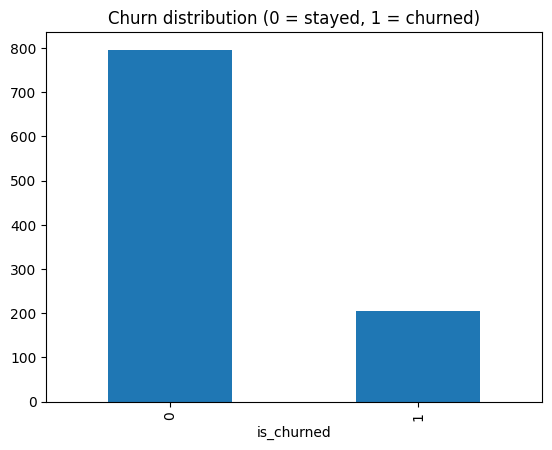

In [5]:
import matplotlib.pyplot as plt

# Check how balanced the target is (churned vs. not churned).
print(merged['is_churned'].value_counts(normalize=True))

merged['is_churned'].value_counts().plot(
    kind='bar', title='Churn distribution (0 = stayed, 1 = churned)'
)
plt.show()


In [6]:
# Check which numeric features correlate most with churn.
# This is just a quick sanity check, not a final feature-selection step.
corr = merged.drop(
    columns=['cust_key', 'customer_id', 'dw_start_date', 'dw_end_date']
).corr()['is_churned'].sort_values(ascending=False)

print(corr)


is_churned                  1.000000
CLV_LTV                     0.118099
avg_total_balance           0.111486
avg_balance_mean            0.106941
last_total_balance          0.077615
avg_ticket_res_time_hrs     0.038402
avg_resolution_time_mean    0.021620
total_accepted_offers       0.016145
last_ticket_count           0.015593
total_usage_events          0.013888
avg_acceptance_rate         0.013654
avg_usage_events            0.008632
months_active              -0.004054
last_usage_events          -0.014673
total_tickets              -0.018840
total_offers               -0.029880
num_products               -0.056644
Name: is_churned, dtype: float64


## 4. Prepare the data for training

We drop ID columns and data-warehouse metadata columns (they carry no predictive signal),
split into train/test sets, and scale the numeric features so the model treats them fairly.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Full list of candidate features (still 16 at this stage).
# We keep ALL of them here on purpose: we need to train one baseline model
# first so the model itself can tell us which features actually matter,
# instead of us guessing.
feature_cols_all = [
    'CLV_LTV', 'avg_ticket_res_time_hrs', 'num_products',
    'months_active', 'total_usage_events', 'avg_usage_events',
    'avg_total_balance', 'avg_balance_mean', 'total_tickets',
    'avg_resolution_time_mean', 'total_offers', 'total_accepted_offers',
    'avg_acceptance_rate', 'last_usage_events', 'last_total_balance', 'last_ticket_count'
]  # 16 features - used ONLY to rank importance, not for the final model

X_all = merged[feature_cols_all]
y = merged['is_churned']

# stratify=y keeps the same churn ratio in both train and test sets.
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

scaler_all = StandardScaler()
X_train_all_s = scaler_all.fit_transform(X_train_all)
X_test_all_s = scaler_all.transform(X_test_all)

print('Train set:', X_train_all.shape, ' Test set:', X_test_all.shape)


Train set: (800, 16)  Test set: (200, 16)


## 5. Train the baseline model (16 features)

We first train a **Random Forest Classifier** on all 16 candidate features.
This baseline is not the final model - its only job is to let us measure
`feature_importances_`, so we can pick the 5 features that actually drive
the prediction, instead of guessing.


In [8]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(
    n_estimators=300,      # number of trees in the forest
    max_depth=8,           # limits tree depth to reduce overfitting
    random_state=42,       # for reproducible results
    class_weight='balanced'  # gives more weight to the minority (churn) class
)

baseline_model.fit(X_train_all_s, y_train)
print('Baseline model (16 features) trained.')


Baseline model (16 features) trained.


## 6. Evaluate the baseline model

In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

pred_all = baseline_model.predict(X_test_all_s)
proba_all = baseline_model.predict_proba(X_test_all_s)[:, 1]

baseline_acc = accuracy_score(y_test, pred_all)
baseline_auc = roc_auc_score(y_test, proba_all)

print('Baseline (16 features) - Accuracy:', baseline_acc)
print('Baseline (16 features) - ROC-AUC:', baseline_auc)
print()
print(classification_report(y_test, pred_all))
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_all))


Baseline (16 features) - Accuracy: 0.78
Baseline (16 features) - ROC-AUC: 0.6608375517717441

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       159
           1       0.44      0.29      0.35        41

    accuracy                           0.78       200
   macro avg       0.64      0.60      0.61       200
weighted avg       0.75      0.78      0.76       200

Confusion matrix:
[[144  15]
 [ 29  12]]


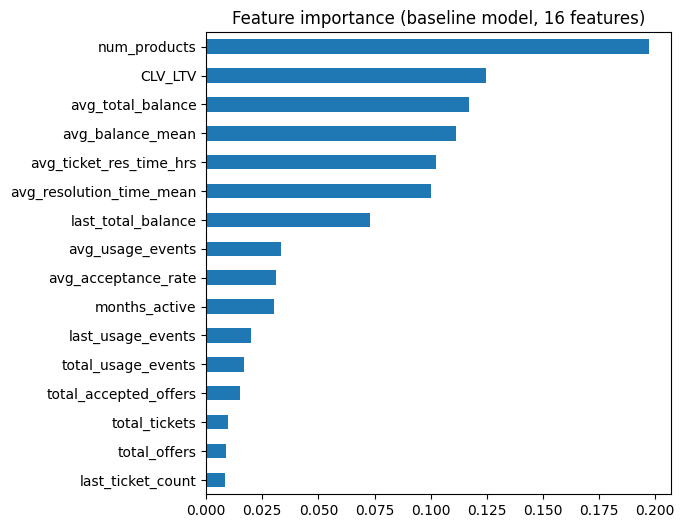

num_products                0.197170
CLV_LTV                     0.124798
avg_total_balance           0.117072
avg_balance_mean            0.111476
avg_ticket_res_time_hrs     0.102312
avg_resolution_time_mean    0.100005
last_total_balance          0.073017
avg_usage_events            0.033259
avg_acceptance_rate         0.031083
months_active               0.030380
last_usage_events           0.019794
total_usage_events          0.017078
total_accepted_offers       0.015076
total_tickets               0.009834
total_offers                0.009050
last_ticket_count           0.008597
dtype: float64


In [10]:
# Ask the model itself which features it actually relied on.
importances = pd.Series(baseline_model.feature_importances_, index=feature_cols_all).sort_values(ascending=False)

importances.plot(kind='barh', figsize=(6, 6), title='Feature importance (baseline model, 16 features)')
plt.gca().invert_yaxis()
plt.show()

print(importances)


## 6b. Select the top 5 features

We don't hand-pick these. We take the 5 features with the highest
`feature_importances_` from the baseline model above - i.e. the 5 the model
itself leaned on the most. Everything else contributed very little, so
keeping them only adds noise/complexity without real accuracy gain.


In [11]:
top5_features = importances.head(5).index.tolist()
print('Top 5 features selected by the model:')
print(top5_features)


Top 5 features selected by the model:
['num_products', 'CLV_LTV', 'avg_total_balance', 'avg_balance_mean', 'avg_ticket_res_time_hrs']


## 6c. Retrain using only the top 5 features, and compare accuracy

Now we build the **final** model using only `top5_features`. We reuse the
exact same train/test split (same customers in each set) so the comparison
with the baseline is fair - only the number of features changes.


In [12]:
# Reuse the same train/test rows, just keep the 5 selected columns.
X_train_5 = X_train_all[top5_features]
X_test_5 = X_test_all[top5_features]

scaler_5 = StandardScaler()
X_train_5_s = scaler_5.fit_transform(X_train_5)
X_test_5_s = scaler_5.transform(X_test_5)

final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)
final_model.fit(X_train_5_s, y_train)

pred_5 = final_model.predict(X_test_5_s)
proba_5 = final_model.predict_proba(X_test_5_s)[:, 1]

acc_5 = accuracy_score(y_test, pred_5)
auc_5 = roc_auc_score(y_test, proba_5)

print(f"{'Metric':<12}{'Baseline (16 feat)':<22}{'Final (5 feat)':<18}{'Diff':<10}")
print(f"{'Accuracy':<12}{baseline_acc:<22.4f}{acc_5:<18.4f}{acc_5 - baseline_acc:+.4f}")
print(f"{'ROC-AUC':<12}{baseline_auc:<22.4f}{auc_5:<18.4f}{auc_5 - baseline_auc:+.4f}")
print()
print('Classification report (5 features):')
print(classification_report(y_test, pred_5))
print('Confusion matrix (5 features):')
print(confusion_matrix(y_test, pred_5))


Metric      Baseline (16 feat)    Final (5 feat)    Diff      
Accuracy    0.7800                0.7500            -0.0300
ROC-AUC     0.6608                0.6964            +0.0356

Classification report (5 features):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       159
           1       0.38      0.34      0.36        41

    accuracy                           0.75       200
   macro avg       0.61      0.60      0.60       200
weighted avg       0.74      0.75      0.75       200

Confusion matrix (5 features):
[[136  23]
 [ 27  14]]


## 7. Save the model

We save the **final model** (trained on the 5 selected features), its
matching scaler, and the 5-feature list - these three are what's needed to
score new customers later (e.g. in the Gradio app).


In [13]:
import joblib

joblib.dump(final_model, 'churn_model.pkl')
joblib.dump(scaler_5, 'churn_scaler.pkl')
joblib.dump(top5_features, 'feature_cols.pkl')

print('Final model (5 features), scaler, and feature list saved.')
print('Features used:', top5_features)


Final model (5 features), scaler, and feature list saved.
Features used: ['num_products', 'CLV_LTV', 'avg_total_balance', 'avg_balance_mean', 'avg_ticket_res_time_hrs']


## 8. Simple Gradio interface

A minimal demo UI: enter a customer's feature values (now only 5) and get a
churn prediction with probability. Running the cell below prints a public
link (because of `share=True`) that you can open from any browser to test
the app live.


In [14]:
import gradio as gr

# Reload artifacts (useful if you're running this cell after restarting the runtime).
model = joblib.load('churn_model.pkl')
scaler = joblib.load('churn_scaler.pkl')
feature_cols = joblib.load('feature_cols.pkl')  # now only the 5 selected features

def predict_churn(*values):
    # Build a single-row DataFrame matching the training feature order.
    row = pd.DataFrame([list(values)], columns=feature_cols)

    row_scaled = scaler.transform(row)
    pred = model.predict(row_scaled)[0]
    proba = model.predict_proba(row_scaled)[0][1]

    label = 'Likely to churn' if pred == 1 else 'Likely to stay'
    return f'{label}\nChurn probability: {proba:.2%}'

# One numeric input field per selected feature (5 fields instead of 16).
inputs = [gr.Number(label=col) for col in feature_cols]

demo = gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=gr.Textbox(label='Prediction'),
    title='Customer Churn Prediction',
    description='Enter a customer\'s feature values to estimate their churn probability.'
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9a84dec09bbe485223.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
